In [ ]:
from prophet import Prophet

import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Load dataset (Ensure it's in a Pandas DataFrame)
df = pd.read_csv("crime_time_series.csv")


In [ ]:
df.rename(columns={'Date': 'ds', 'Crime_Count_30D': 'y'}, inplace=True)


In [ ]:
df['ds'] = pd.to_datetime(df['ds'])


In [ ]:
from prophet import Prophet

# Initialize the model
model = Prophet()


In [ ]:
model.fit(df)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp7_17s15e/t1yflc5r.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7_17s15e/ta_qh43a.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=77635', 'data', 'file=/tmp/tmp7_17s15e/t1yflc5r.json', 'init=/tmp/tmp7_17s15e/ta_qh43a.json', 'output', 'file=/tmp/tmp7_17s15e/prophet_modelq86oqzey/prophet_model-20250403123654.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:36:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:39:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=30, freq='D')  # Change periods as needed


In [ ]:
print(future)

                        ds
0      2001-01-01 00:00:00
1      2001-01-01 00:01:00
2      2001-01-01 00:10:00
3      2001-01-01 00:15:00
4      2001-01-01 00:20:00
...                    ...
244564 2023-08-09 23:50:00
244565 2023-08-10 23:50:00
244566 2023-08-11 23:50:00
244567 2023-08-12 23:50:00
244568 2023-08-13 23:50:00

[244569 rows x 1 columns]


In [ ]:
forecast = model.predict(future)


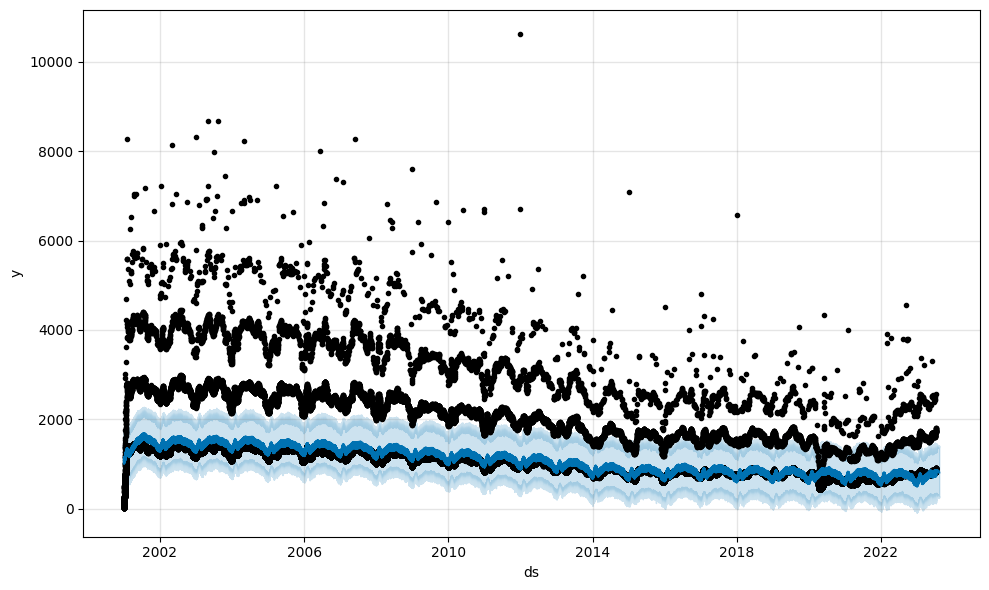

In [ ]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)
plt.show()


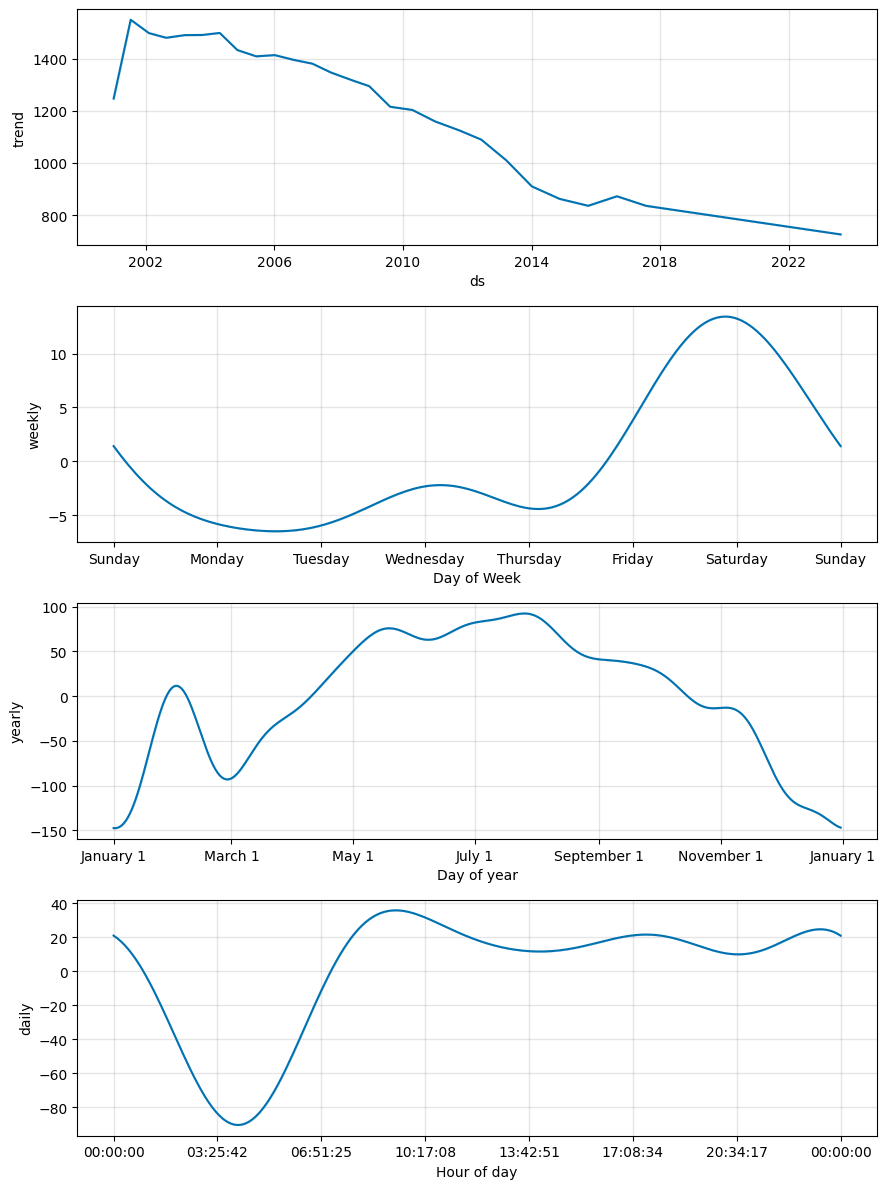

In [ ]:
fig2 = model.plot_components(forecast)
plt.show()


In [ ]:
min_len = min(len(actual), len(predicted))
actual = actual[:min_len]
predicted = predicted[:min_len]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(actual, predicted)
rmse = mean_squared_error(actual, predicted) ** 0.5

mape = np.mean(np.abs((actual - predicted) / actual)) * 100  # MAPE

print(f"✅ MAE: {mae:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAPE: {mape:.2f}%")


✅ MAE: 229.5490
✅ RMSE: 434.2510
✅ MAPE: 18.00%
